In [ ]:
#cspell:words backtest DEMA SUPERTREND
import config as cfg
import pandas as pd
import numpy as np
import indicators as ind
import data
import matplotlib.pyplot as plt

"""TODO: Ensure sizing doesn't exceed account size. Track this using dynamic money_available rather than calculating it at the end. Also implement margins and leverage."""

'TODO: Fix sizing and the fact that it appears im going all in on every trade.'

In [167]:
import importlib

#cspell:words backtest DEMA xlabel ylabel sharex figsize
importlib.reload(cfg)
importlib.reload(ind)
importlib.reload(data)
df = data.df.dropna()

st = ind.SuperTrend(df)

indicator_df = pd.DataFrame({
    'ATR': ind.ATR(df).calculate(),
    'SuperTrend': st.calculate(),
    'SuperTrend_Flip': st.get_flip_signals(),
    'ADX': ind.ADX(df).calculate(),
    'RSI': ind.RSI(df).calculate(),
    'DEMA': ind.DEMA(df).calculate(),
}, index=df.index).interpolate(method='time', limit_area='inside')

[*********************100%***********************]  1 of 1 completed


In [168]:
#cspell:words Buy Sell DEMA RSI ADX ATR SuperTrend
df["Buy"] = (
    (df["Close"] > indicator_df["DEMA"]) &
    (indicator_df["RSI"] > 55) &
    (indicator_df["ADX"] > 30) &
    (indicator_df["ATR"] > 0) &
    (indicator_df["SuperTrend"] < df["Close"])
).fillna(False)

df["Sell"] = (
    (df["Close"] < indicator_df["DEMA"]) &
    (indicator_df["RSI"] < 45) &
    (indicator_df["ADX"] > 30) &
    (indicator_df["ATR"] > 0) &
    (indicator_df["SuperTrend"] > df["Close"])
).fillna(False)


In [ ]:
position = None
current_trade = None
trades = []
equity_curve = []
equity_current = cfg.ACCOUNT_SIZE

for ts, row in df.iterrows():
    # exit first (at close)
    if position is not None and indicator_df.loc[ts, "SuperTrend_Flip"]:
        current_trade["Exit Date"] = ts
        current_trade["Exit Price"] = row.Close
        pnl = current_trade["Shares"] * (row.Close - current_trade["Entry Price"])
        current_trade["PnL"] = pnl
        equity_current = current_trade["Entry Equity"] + pnl
        current_trade["Exit Equity"] = equity_current
        trades.append(current_trade)
        position = None
        current_trade = None

    # entries (at close)
    if row.Buy and position != "Long":
        shares = (equity_current * cfg.PERCENTAGE_INVESTED) / (row.Close - indicator_df.loc[ts, "SuperTrend"]) 
        current_trade = {
            "Entry Date": ts,
            "Entry Price": row.Close,
            "Type": "Long",
            "Shares": shares,
            "Entry Equity": equity_current,
        }
        position = "Long"
    elif row.Sell and position != "Short":
        percentage = cfg.PERCENTAGE_INVESTED
        if percentage > 1:
            percentage /= 100
        shares = (equity_current * percentage) / (indicator_df.loc[ts, "SuperTrend"] - row.Close)
        current_trade = {
            "Entry Date": ts,
            "Entry Price": row.Close,
            "Type": "Short",
            "Shares": -shares,
            "Entry Equity": equity_current,
        }
        position = "Short"

    # mark-to-market equity for this bar
    if position is not None and current_trade is not None:
        pnl = current_trade["Shares"] * (row.Close - current_trade["Entry Price"])
        equity_point = current_trade["Entry Equity"] + pnl
    else:
        equity_point = equity_current

    equity_curve.append(equity_point)

# close any open trade at the last bar
if current_trade is not None:
    last_ts = df.index[-1]
    last_price = df["Close"].iloc[-1]
    current_trade["Exit Date"] = last_ts
    current_trade["Exit Price"] = last_price
    pnl = current_trade["Shares"] * (last_price - current_trade["Entry Price"])
    current_trade["PnL"] = pnl
    equity_current = current_trade["Entry Equity"] + pnl
    current_trade["Exit Equity"] = equity_current
    trades.append(current_trade)
    equity_curve[-1] = equity_current

equity = pd.Series(equity_curve, index=df.index)
money_available = pd.Series(float(cfg.ACCOUNT_SIZE), index=df.index)
for _, trade in pd.DataFrame(trades).iterrows():
    mask = df.index >= trade["Entry Date"]
    money_available.loc[mask] = trade["Entry Equity"] - abs(trade["Shares"] * trade["Entry Price"])
    mask = df.index >= trade["Exit Date"]
    money_available.loc[mask] = trade["Exit Equity"]
trades = pd.DataFrame(trades)


In [170]:
total_PnL_pct = (equity.iloc[-1] - cfg.ACCOUNT_SIZE) / cfg.ACCOUNT_SIZE
total_PnL = (equity.iloc[-1] - cfg.ACCOUNT_SIZE)

In [171]:
equity_curve = []
for row in df.itertuples():
    if position == "Long":
        equity_curve.append((row.Close - current_trade["Entry Price"]) / current_trade["Entry Price"])
    elif position == "Short":
        equity_curve.append((current_trade["Entry Price"] - row.Close) / current_trade["Entry Price"])
    else:
        equity_curve.append(0)

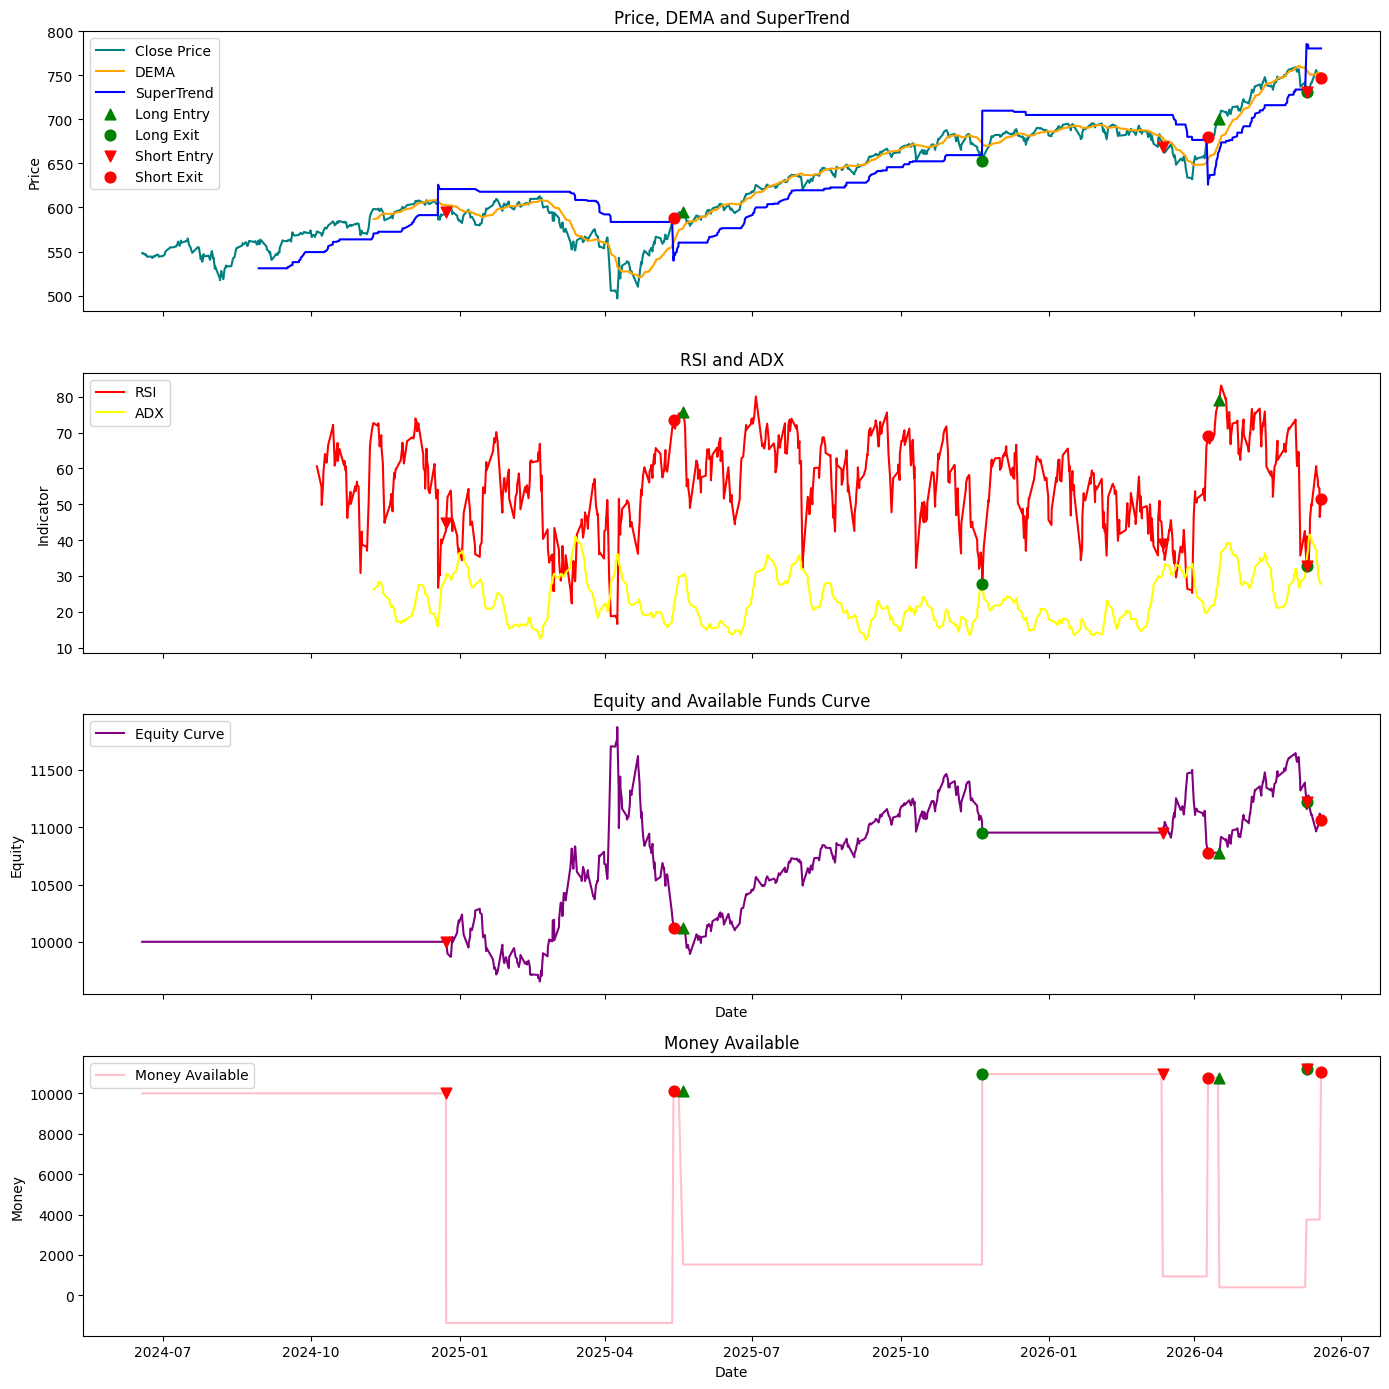

Total PnL: 10.61%
Total PnL: $1061.04


In [172]:
#cspell:words Buy Sell DEMA RSI ADX ATR SuperTrend sharex figsize ylabel, xlabel zorder
fig, (ax1, ax2, ax3, ax4) = plt.subplots(4, 1, sharex=True, figsize=(14, 14))

ax1.plot(df.index, df["Close"], label="Close Price", color="teal")
ax1.plot(indicator_df.index, indicator_df["DEMA"], label="DEMA", color="orange")
ax1.plot(indicator_df.index, indicator_df["SuperTrend"], label="SuperTrend", color="blue")
ax1.set_title("Price, DEMA and SuperTrend")
ax1.set_ylabel("Price")
ax1.legend(loc="upper left")

ax2.plot(indicator_df.index, indicator_df["RSI"], label="RSI", color="red")
ax2.plot(indicator_df.index, indicator_df["ADX"], label="ADX", color="yellow")
ax2.set_title("RSI and ADX")
ax2.set_ylabel("Indicator")
ax2.legend(loc="upper left")

ax3.plot(equity.index, equity, label="Equity Curve", color="purple")
ax3.set_title("Equity and Available Funds Curve")
ax3.set_ylabel("Equity")
ax3.set_xlabel("Date")
ax3.legend(loc="upper left")

ax4.plot(money_available.index, money_available, label="Money Available", color="pink")
ax4.set_title("Money Available")
ax4.set_ylabel("Money")
ax4.set_xlabel("Date")
ax4.legend(loc="upper left")

if not trades.empty:
    longs = trades[trades["Type"] == "Long"]
    shorts = trades[trades["Type"] == "Short"]

    if not longs.empty:
        ax1.scatter(longs["Entry Date"], longs["Entry Price"], marker="^", color="green", s=60, label="Long Entry", zorder=5)
        ax1.scatter(longs["Exit Date"], longs["Exit Price"], marker="o", color="green", s=60, label="Long Exit", zorder=5)
        ax2.scatter(longs["Entry Date"], indicator_df.loc[longs["Entry Date"], "RSI"], marker="^", color="green", s=60, label="Long Entry", zorder=5)
        ax2.scatter(longs["Exit Date"], indicator_df.loc[longs["Exit Date"], "RSI"], marker="o", color="green", s=60, label="Long Exit", zorder=5)
        ax3.scatter(longs["Entry Date"], longs["Entry Equity"], marker="^", color="green", s=60, label="Long Entry", zorder=5)
        ax3.scatter(longs["Exit Date"], longs["Exit Equity"], marker="o", color="green", s=60, label="Long Exit", zorder=5)
        ax4.scatter(longs["Entry Date"], longs["Entry Equity"], marker="^", color="green", s=60, label="Long Entry", zorder=5)
        ax4.scatter(longs["Exit Date"], longs["Exit Equity"], marker="o", color="green", s=60, label="Long Exit", zorder=5)

    if not shorts.empty:
        ax1.scatter(shorts["Entry Date"], shorts["Entry Price"], marker="v", color="red", s=60, label="Short Entry", zorder=5)
        ax1.scatter(shorts["Exit Date"], shorts["Exit Price"], marker="o", color="red", s=60, label="Short Exit", zorder=5)
        ax2.scatter(shorts["Entry Date"], indicator_df.loc[shorts["Entry Date"], "RSI"], marker="v", color="red", s=60, label="Short Entry", zorder=5)
        ax2.scatter(shorts["Exit Date"], indicator_df.loc[shorts["Exit Date"], "RSI"], marker="o", color="red", s=60, label="Short Exit", zorder=5)
        ax3.scatter(shorts["Entry Date"], shorts["Entry Equity"], marker="v", color="red", s=60, label="Short Entry", zorder=5)
        ax3.scatter(shorts["Exit Date"], shorts["Exit Equity"], marker="o", color="red", s=60, label="Short Exit", zorder=5)
        ax4.scatter(shorts["Entry Date"], shorts["Entry Equity"], marker="v", color="red", s=60, label="Short Entry", zorder=5)
        ax4.scatter(shorts["Exit Date"], shorts["Exit Equity"], marker="o", color="red", s=60, label="Short Exit", zorder=5)

    ax1.legend(loc="upper left")

plt.tight_layout()
plt.show()
print(f"Total PnL: {total_PnL_pct:.2%}")
print(f"Total PnL: ${total_PnL:.2f}")